# Hw2.1 - Коефіцієнт народжуваності в регіонах України

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Зчитування даних з Вікіпедії

In [38]:
url = 'https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%BD%D0%BE%D1%81%D1%82%D1%8C_%D0%B2_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D1%96'

try:
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    response = requests.get(url, headers=headers, timeout=10)
    tables = pd.read_html(StringIO(response.text), decimal=',', thousands=' ')
    df = tables[1].copy()
    print('Data loaded from Wikipedia')
except Exception as e:
    # Fallback data
    data = {
        'Регіон': ['Вінницька', 'Волинська', 'Дніпропетровська', 'Донецька', 'Житомирська',
                   'Закарпатська', 'Івано-Франківська', 'Київська', 'Кіровоградська', 'Луганська',
                   'Львівська', 'Миколаївська', 'Одеська', 'Полтавська', 'Рівненська',
                   'Сумська', 'Тернопільська', 'Харківська', 'Херсонська', 'Хмельницька',
                   'Черкаська', 'Чернівецька', 'Чернігівська', 'Київ', 'Севастополь', 'Україна'],
        '2010': [9.7, 11.4, 9.3, 8.5, 9.1, 11.3, 10.2, 10.3, 9.6, 8.3, 10.1, 9.0, 9.5, 9.0, 11.5, 8.8, 9.3, 9.8, 9.6, 9.2, 9.1, 10.5, 8.6, 10.5, 9.7, 9.5],
        '2014': [9.2, 11.4, 9.3, None, 8.8, 11.4, 10.1, 10.7, 9.0, None, 10.6, 8.9, 9.2, 8.7, 11.6, 8.5, 9.1, 9.9, 9.0, 9.1, 9.2, 10.4, 8.3, 11.5, 9.3, 10.4],
        '2019': [7.5, 9.8, 8.1, None, 7.6, 10.1, 9.2, 7.9, 7.3, None, 8.2, 7.6, 9.2, 7.8, 10.2, 7.2, 8.9, 8.7, 9.1, 9.2, 7.9, 9.8, 7.1, 9.5, 7.8, 8.6]
    }
    df = pd.DataFrame(data)
    print('Using fallback data')

print(f'Shape: {df.shape}')

Using fallback data
Shape: (26, 4)


## Вивести перші рядки таблиці за допомогою методу head

In [39]:
df.head()

,Регіон,2010,2014,2019
0,Вінницька,9.7,9.2,7.5
1,Волинська,11.4,11.4,9.8
2,Дніпропетровська,9.3,9.3,8.1
3,Донецька,8.5,NaN,NaN
4,Житомирська,9.1,8.8,7.6


## Визначте кількість рядків та стовпців у датафреймі (атрибут shape)

In [40]:
df.shape

(26, 4)

## Замініть у таблиці значення "-" на значення NaN

In [57]:
df = df.replace('—', np.nan)
df = df.replace('-', np.nan)
df.head()

,Регіон,2010,2014,2019
0,Вінницька,9.7,9.2,7.5
1,Волинська,11.4,11.4,9.8
2,Дніпропетровська,9.3,9.3,8.1
3,Донецька,8.5,NaN,NaN
4,Житомирська,9.1,8.8,7.6


## Визначте типи всіх стовпців за допомогою dataframe.dtypes

In [42]:
df.dtypes

Регіон        str
2010      float64
2014      float64
2019      float64
dtype: object

## Замініть типи нечислових колонок на числові

In [43]:
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes

Регіон        str
2010      float64
2014      float64
2019      float64
dtype: object

## Порахуйте частку пропусків в кожній колонці

In [44]:
missing_pct = df.isnull().sum() / len(df) * 100
missing_pct

Регіон    0.000000
2010      0.000000
2014      7.692308
2019      7.692308
dtype: float64

## Видаліть з таблиці дані по всій країні (останній рядок)

In [45]:
df = df[:-1]
df.shape

(25, 4)

## Замініть відсутні дані в стовпцях середніми значеннями

In [46]:
for col in df.columns[1:]:
    df[col].fillna(df[col].mean(), inplace=True)

df.isnull().sum()

Регіон    0
2010      0
2014      2
2019      2
dtype: int64

## Список регіонів, де рівень народжуваності у 2019 році був вищим за середній

In [47]:
avg_2019 = df['2019'].mean()
print(f'Середній рівень народжуваності у 2019: {avg_2019:.2f}')
regions_above_avg = df[df['2019'] > avg_2019]['Регіон'].tolist()
print(f'Регіони з рівнем народжуваності вище середнього: {regions_above_avg}')

Середній рівень народжуваності у 2019: 8.51
Регіони з рівнем народжуваності вище середнього: ['Волинська', 'Закарпатська', 'Івано-Франківська', 'Одеська', 'Рівненська', 'Тернопільська', 'Харківська', 'Херсонська', 'Хмельницька', 'Чернівецька', 'Київ']


## Регіон з найвищою народжуваністю у 2014 році

In [48]:
max_2014_idx = df['2014'].idxmax()
print(f'Найвища народжуваність у 2014: {df.loc[max_2014_idx, "Регіон"]} ({df.loc[max_2014_idx, "2014"]})')

Найвища народжуваність у 2014: Рівненська (11.6)


## Графік 1: Стовпчикова діаграма народжуваності по регіонах у 2019 році

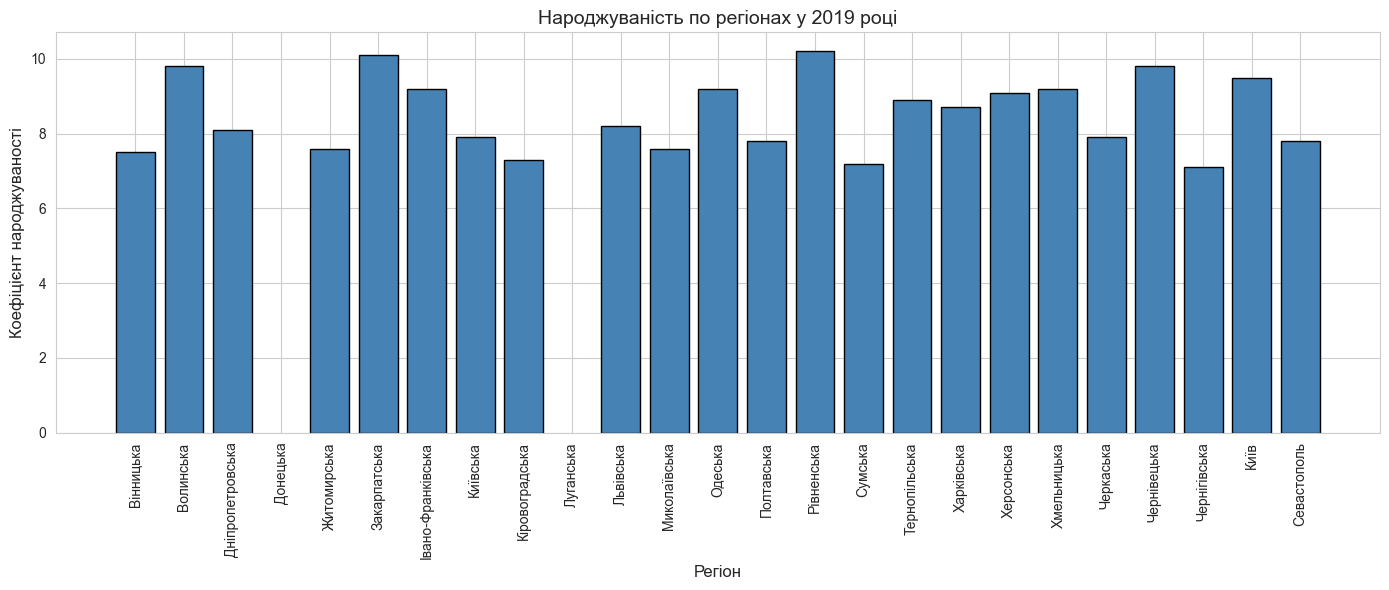

In [49]:
plt.figure(figsize=(14, 6))
plt.bar(df['Регіон'], df['2019'], color='steelblue', edgecolor='black')
plt.title('Народжуваність по регіонах у 2019 році', fontsize=14)
plt.xlabel('Регіон', fontsize=12)
plt.ylabel('Коефіцієнт народжуваності', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Графік 2: Порівняння народжуваності 2010, 2014, 2019

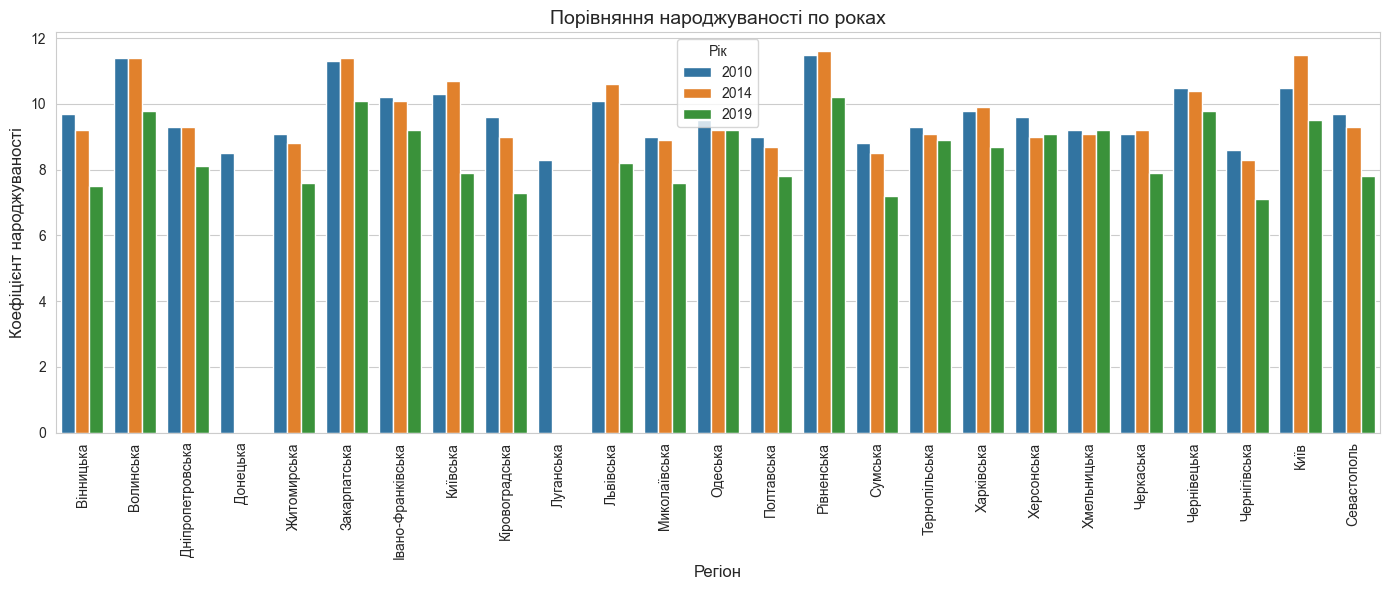

In [50]:
df_melted = df.melt(id_vars=['Регіон'], value_vars=['2010', '2014', '2019'], 
                    var_name='Рік', value_name='Народжуваність')

plt.figure(figsize=(14, 6))
sns.barplot(data=df_melted, x='Регіон', y='Народжуваність', hue='Рік')
plt.title('Порівняння народжуваності по роках', fontsize=14)
plt.xlabel('Регіон', fontsize=12)
plt.ylabel('Коефіцієнт народжуваності', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Рік')
plt.tight_layout()
plt.show()

## Графік 3: Boxplot народжуваності по роках

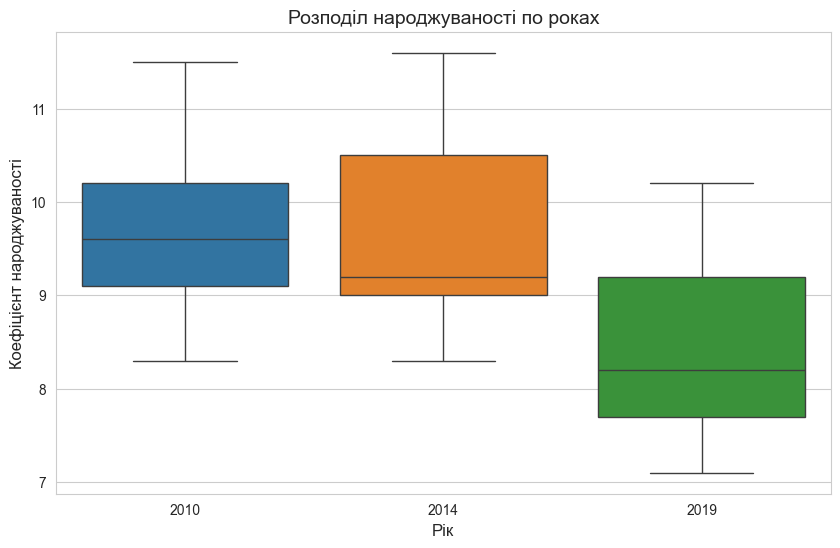

In [51]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['2010', '2014', '2019']])
plt.title('Розподіл народжуваності по роках', fontsize=14)
plt.xlabel('Рік', fontsize=12)
plt.ylabel('Коефіцієнт народжуваності', fontsize=12)
plt.show()

## Графік 4: Heatmap кореляції між роками

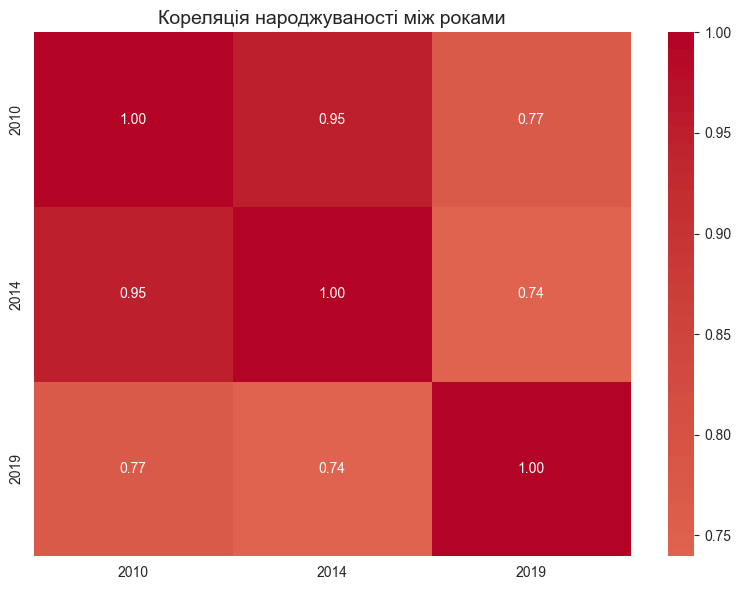

In [52]:
corr_matrix = df[['2010', '2014', '2019']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Кореляція народжуваності між роками', fontsize=14)
plt.tight_layout()
plt.show()

## Графік 5: Line plot зміни народжуваності по регіонах

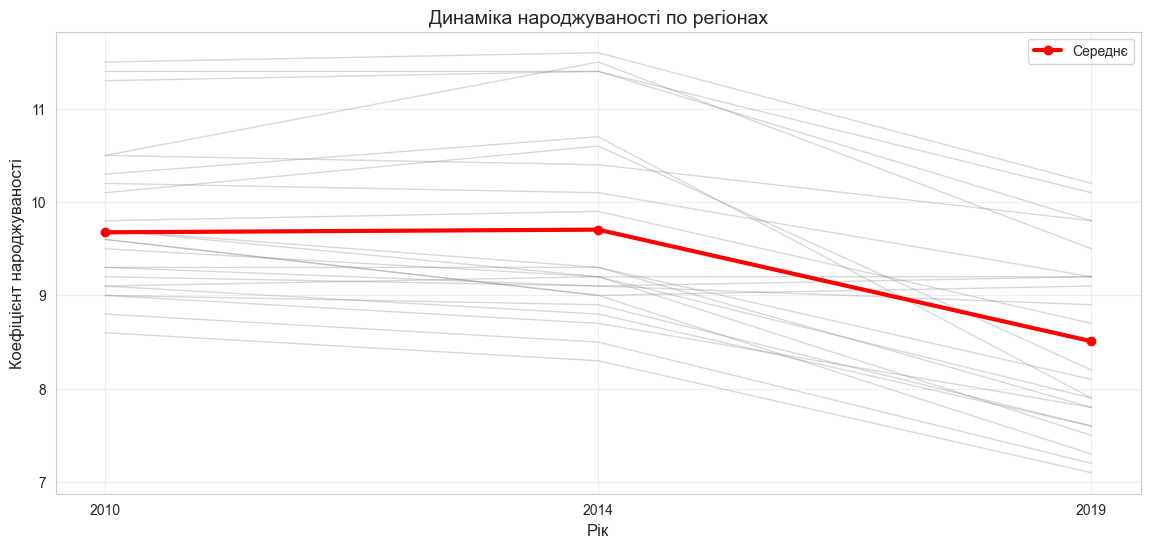

In [53]:
plt.figure(figsize=(14, 6))
for idx, row in df.iterrows():
    plt.plot(['2010', '2014', '2019'], [row['2010'], row['2014'], row['2019']], 
             alpha=0.3, color='gray', linewidth=1)

plt.plot(['2010', '2014', '2019'], [df['2010'].mean(), df['2014'].mean(), df['2019'].mean()], 
         color='red', linewidth=3, marker='o', label='Середнє')
plt.title('Динаміка народжуваності по регіонах', fontsize=14)
plt.xlabel('Рік', fontsize=12)
plt.ylabel('Коефіцієнт народжуваності', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()